In [1]:
import numpy as np
import itertools
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff
import matplotlib.pyplot as plt

In [2]:
dim = 2
mpl = 1.221e19
Pi = 100**0.5
M = 1e16 / mpl
phic = np.sqrt(2) * M
Lambda = 5.4e15 / mpl * (Pi / 10)**(-1) * M * phic**0.5
nWaterfall = 1
mu1 = Pi**2 * M**(-2) * phic**(-1)
mu2 = 10
psirc = (nWaterfall * Lambda**4 * Pi / 48 / 2**0.5 / np.pi**1.5)**0.5

def infPotFunc(Phi):
    phi = Phi[0]
    psir = Phi[1]
    return float(Lambda**4 * ((1 - (psir / M)**2)**2 + 2 * (phi * psir / phic / M)**2 + (phi - phic) / mu1 - ((phi - phic) / mu2)**2))
    
def infPotDerivFunc_phi(Phi):
    phi = Phi[0]
    psir = Phi[1]
    return float(Lambda**4 * (4 * phi * (psir / phic / M)**2 + 1 / mu1 - 2 * (phi - phic) / mu2**2))
    
def infPotDerivFunc_psir(Phi):
    phi = Phi[0]
    psir = Phi[1]
    return float(Lambda**4 * (-4 * psir / M**2 * (1 - (psir / M)**2) + 4 * psir * (phi / phic / M)**2))

def infPotDeriv2Func_phi(Phi):
    psir = Phi[1]
    return float(Lambda**4 * (4 * (psir / phic / M)**2 - 2 / mu2**2))

def infPotDeriv2Func_psir(Phi):
    phi = Phi[0]
    psir = Phi[1]
    return float(Lambda**4 * (-4 / M**2 + 12 * (psir / M / M)**2 + 4 * (phi / phic / M)**2))


infPotentialDerivFuncs = [infPotDerivFunc_phi, infPotDerivFunc_psir]
infPotentialDeriv2Funcs = [infPotDeriv2Func_phi, infPotDeriv2Func_psir]

nGrid = 64
phimin = 0.999995 * phic
phimax = phic + 20 / mu1
psimax = 1e-4 * M
psimin = 0.1 * psirc
customGrid_phi = np.linspace(phimin, phimax, nGrid)
customGrid_psir = np.exp(np.linspace(np.log(psimin), np.log(psimax), nGrid))

In [3]:
phitest = phimin
psirtest = customGrid_psir[1]
Phitest = np.array([phitest, psirtest])
print(infPotFunc(Phitest))
print(infPotDerivFunc_phi(Phitest))
print((infPotFunc(Phitest + np.array([phitest * 0.01, 0])) - infPotFunc(Phitest - np.array([phitest * 0.01, 0]))) / (phitest * 0.02))
print(infPotDerivFunc_psir(Phitest))
print((infPotFunc(Phitest + np.array([0, psirtest * 0.001])) - infPotFunc(Phitest - np.array([0, psirtest * 0.001]))) / (psirtest * 0.002))
print(infPotDeriv2Func_phi(Phitest))
print((infPotDerivFunc_phi(Phitest + np.array([phitest * 0.01, 0])) - infPotDerivFunc_phi(Phitest - np.array([phitest * 0.01, 0]))) / (phitest * 0.02))
print(infPotDeriv2Func_psir(Phitest))
print((infPotDerivFunc_psir(Phitest + np.array([0, psirtest * 0.01])) - infPotDerivFunc_psir(Phitest - np.array([0, psirtest * 0.01]))) / (psirtest * 0.02))

2.309130063155654e-32
2.8539290807947685e-42
2.7174487551341525e-42
-4.9993230818822826e-48
0.0
-4.618260126311308e-34
-4.618260126311298e-34
-1.3770148664584386e-30
-1.3770148662232464e-30


In [4]:
customGrid_psir

array([2.47163124e-18, 3.63055128e-18, 5.33287586e-18, 7.83340126e-18,
       1.15063949e-17, 1.69016137e-17, 2.48265900e-17, 3.64674983e-17,
       5.35666973e-17, 7.86835181e-17, 1.15577333e-16, 1.69770242e-16,
       2.49373596e-16, 3.66302065e-16, 5.38056976e-16, 7.90345830e-16,
       1.16093008e-15, 1.70527712e-15, 2.50486235e-15, 3.67936408e-15,
       5.40457643e-15, 7.93872142e-15, 1.16610984e-14, 1.71288561e-14,
       2.51603837e-14, 3.69578042e-14, 5.42869021e-14, 7.97414188e-14,
       1.17131272e-13, 1.72052805e-13, 2.52726427e-13, 3.71227000e-13,
       5.45291158e-13, 8.00972038e-13, 1.17653880e-12, 1.72820459e-12,
       2.53854025e-12, 3.72883316e-12, 5.47724102e-12, 8.04545761e-12,
       1.18178820e-11, 1.73591538e-11, 2.54986654e-11, 3.74547022e-11,
       5.50167901e-11, 8.08135430e-11, 1.18706103e-10, 1.74366057e-10,
       2.56124336e-10, 3.76218151e-10, 5.52622603e-10, 8.11741115e-10,
       1.19235738e-09, 1.75144032e-09, 2.57267094e-09, 3.77896736e-09,
      

In [5]:
fpFinDiff_NeuNeu = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, psimin],
    ["Neumann0", "Neumann0"],
    ["Neumann0", "Neumann0"],
    customGrid=[customGrid_phi, customGrid_psir],
    set0OutOfInfRegion=False
)

# ポテンシャルが一定以下ならインフレーション領域外として、当該点に対応する行列の要素を0とする
customGrid_phi_woEnd = customGrid_phi[1:-1]
customGrid_psir_woEnd = customGrid_psir[1:-1]
vTh = (1 - 4.746948205088901201275e-16) * Lambda**4
maskMat = np.full((len(customGrid_phi_woEnd), len(customGrid_psir_woEnd)), False)
for i1 in range(len(customGrid_phi_woEnd)):
    for i2 in range(len(customGrid_psir_woEnd)):
        if infPotFunc([customGrid_phi_woEnd[i1], customGrid_phi_woEnd[i2]]) < vTh:
            maskMat[i1, i2] = True
            fpFinDiff_NeuNeu[i1, i2] = 0

eigVals_NeuNeu, eigVecs_NeuNeu = np.linalg.eig(fpFinDiff_NeuNeu)
eigVecsSort_NeuNeu = eigVecs_NeuNeu.T[np.argsort(eigVals_NeuNeu)]
eigValsSort_NeuNeu = np.sort(eigVals_NeuNeu)

In [6]:
fpFinDiff_DirDir = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, psimin],
    ["Dirichlet", "Dirichlet"],
    ["Dirichlet", "Neumann0"],
    customGrid=[customGrid_phi, customGrid_psir],
    set0OutOfInfRegion=False
)

for i1 in range(len(customGrid_phi_woEnd)):
    for i2 in range(len(customGrid_psir_woEnd)):
        if maskMat[i1, i2]: fpFinDiff_DirDir[i1, i2] = 0

eigVals_DirDir, eigVecs_DirDir = np.linalg.eig(fpFinDiff_DirDir)
eigVecsSort_DirDir = eigVecs_DirDir.T[np.argsort(eigVals_DirDir)]
eigValsSort_DirDir = np.sort(eigVals_DirDir)

c:\Users\koich\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


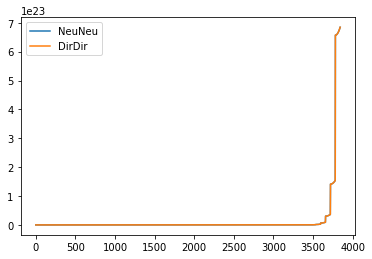

In [7]:
ax = plt.gca()
plt.plot(eigValsSort_NeuNeu, label = "NeuNeu")
plt.plot(eigValsSort_DirDir, label = "DirDir")
plt.legend()
plt.show()

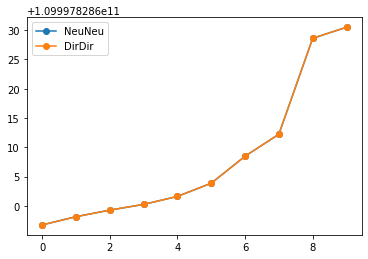

In [8]:
ax = plt.gca()
plt.plot(np.arange(10), eigValsSort_NeuNeu[:10], marker='o', label = "NeuNeu")
plt.plot(np.arange(10), eigValsSort_DirDir[:10], marker='o', label = "DirDir")
plt.legend()
plt.show()

In [9]:
np.set_printoptions(formatter={'complexfloat': '{:.30f}'.format})
print(eigValsSort_NeuNeu[0:10])
print(eigValsSort_DirDir[0:10])
np.set_printoptions()

[109997828596.736495971679687500000000000000+0.000000000000000000000000000000j
 109997828598.141357421875000000000000000000+0.000000000000000000000000000000j
 109997828599.263458251953125000000000000000+0.000000000000000000000000000000j
 109997828600.238357543945312500000000000000+0.000000000000000000000000000000j
 109997828601.606796264648437500000000000000+0.000000000000000000000000000000j
 109997828603.855499267578125000000000000000+0.000000000000000000000000000000j
 109997828608.466720581054687500000000000000+0.000000000000000000000000000000j
 109997828612.225479125976562500000000000000+0.000000000000000000000000000000j
 109997828628.604675292968750000000000000000+0.000000000000000000000000000000j
 109997828630.489898681640625000000000000000+0.000000000000000000000000000000j]
[109997828596.736190795898437500000000000000+0.000000000000000000000000000000j
 109997828598.141342163085937500000000000000+0.000000000000000000000000000000j
 109997828599.263183593750000000000000000000+0.0000

「phi上下端：ノイマン、psir上下端：ノイマン」と「phi上下端：ディリクレ、psir上端：ディリクレ、psir下端：ノイマン」で、固有値ほぼ一致

c:\Users\koich\anaconda3\lib\site-packages\matplotlib\contour.py:1454: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = float(z.max())
c:\Users\koich\anaconda3\lib\site-packages\matplotlib\contour.py:1455: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = float(z.min())
c:\Users\koich\anaconda3\lib\site-packages\numpy\ma\core.py:2825: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


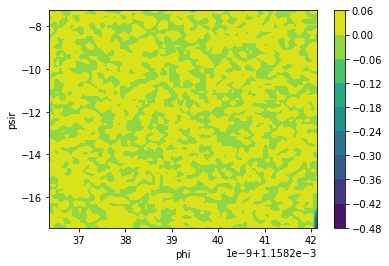

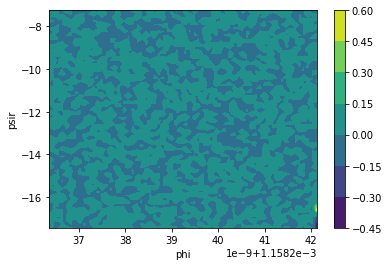

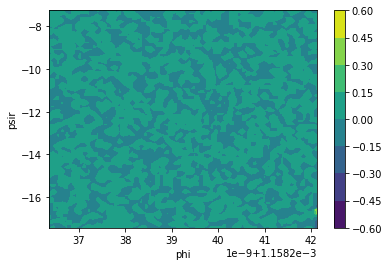

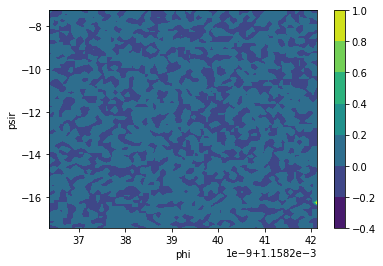

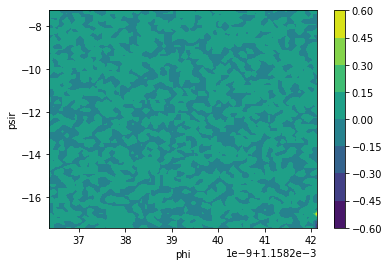

In [23]:
# 固有関数のプロット
for iEig in range(5):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(customGrid_phi[1:-1], np.log10(customGrid_psir[1:-1]), np.reshape(eigVecsSort_NeuNeu[iEig], (nGrid-2, nGrid-2)).T)
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi")
    ax1.set_ylabel("psir")
    plt.show()

c:\Users\koich\anaconda3\lib\site-packages\matplotlib\contour.py:1454: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = float(z.max())
c:\Users\koich\anaconda3\lib\site-packages\matplotlib\contour.py:1455: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = float(z.min())
c:\Users\koich\anaconda3\lib\site-packages\numpy\ma\core.py:2825: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


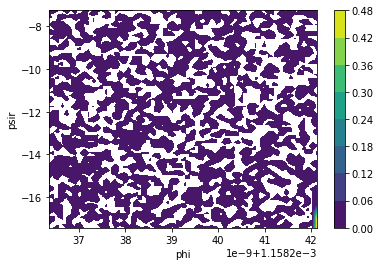

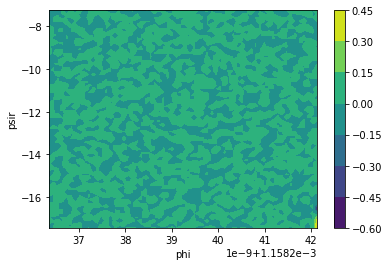

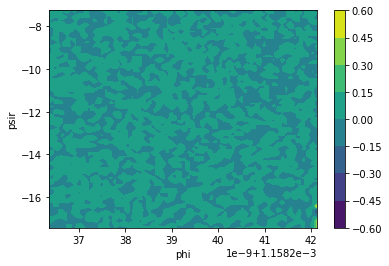

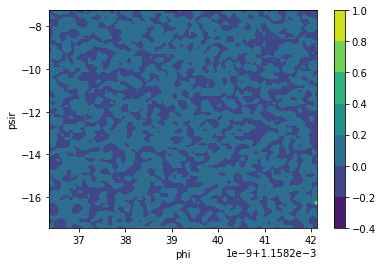

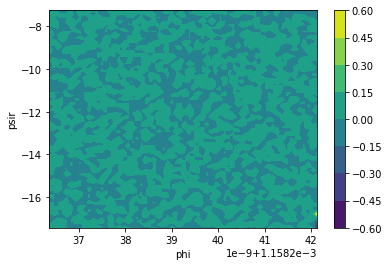

In [22]:
# 固有関数のプロット
for iEig in range(5):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(customGrid_phi[1:-1], np.log10(customGrid_psir[1:-1]), np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2)).T)
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi")
    ax1.set_ylabel("psir")
    plt.show()